# Lab 7 – NLP Document Preprocessing & TF-IDF
### Aim
- Apply Tokenization, POS Tagging, Stop-words Removal, Stemming, and Lemmatization.
- Compute Term Frequency – Inverse Document Frequency (TF-IDF) representation.

-pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [44]:
# Cell 1 – Importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import re

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='muted')

In [45]:
# Cell 2 – NLTK Downloads
import nltk, ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'wordnet_ic',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

print('NLTK data ready.')

NLTK data ready.


In [46]:
# Cell 3 – Create Sample Documents
sample_documents = [
    "Natural language processing is a subfield of linguistics, computer science, and artificial intelligence.",
    "Machine learning is the study of computer algorithms that improve automatically through experience.",
    "Data science combines statistics, programming, and domain expertise to extract insights from data.",
    "Artificial intelligence aims to create machines that can perform tasks that typically require human intelligence.",
    "Text mining is the process of deriving high-quality information from text.",
    "Sentiment analysis determines the emotional tone behind a series of words.",
    "Named entity recognition identifies and classifies named entities in text.",
    "Topic modeling discovers abstract topics in a collection of documents.",
    "Word embeddings represent words as vectors in a continuous vector space.",
    "Chatbots use natural language processing to simulate human conversation.",
]

df = pd.DataFrame({'document': sample_documents})
df.head()

,document
0,Natural language processing is a subfield of l...
1,Machine learning is the study of computer algo...
2,"Data science combines statistics, programming,..."
3,Artificial intelligence aims to create machine...
4,Text mining is the process of deriving high-qu...


In [47]:
# Cell 4 – EDA: Shape, Info, Describe
print('Shape:', df.shape)
print('Size :', df.size)
print()

df.info()

df['text_length'] = df['document'].apply(len)
print()
print('Text length stats:')
print(df['text_length'].describe())

Shape: (10, 1)
Size : 10

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   document  10 non-null     str  
dtypes: str(1)
memory usage: 212.0 bytes

Text length stats:
count     10.00000
mean      85.00000
std       16.45195
min       70.00000
25%       72.50000
50%       74.00000
75%       98.75000
max      113.00000
Name: text_length, dtype: float64


In [48]:
# Cell 5 – Sample Preview
print('Sample documents:')
for i, doc in enumerate(df['document'][:3]):
    print(f'  Doc {i+1}: {doc[:90]}...')

Sample documents:
  Doc 1: Natural language processing is a subfield of linguistics, computer science, and artificial...
  Doc 2: Machine learning is the study of computer algorithms that improve automatically through ex...
  Doc 3: Data science combines statistics, programming, and domain expertise to extract insights fr...


In [49]:
# Cell 6 – Insert Null / Empty Rows (simulate dirty data)
null_rows = pd.DataFrame([
    {'document': 'This is a sample document with some content.'},
    {'document': ''},
    {'document': np.nan},
])

insert_pos = 3
df_with_null = pd.concat(
    [df.iloc[:insert_pos], null_rows, df.iloc[insert_pos:]]
).reset_index(drop=True)

print('New shape with inserted rows:', df_with_null.shape)
print('\nNull counts before removal:')
print(df_with_null.isnull().sum())
print('Empty documents:', (df_with_null['document'] == '').sum())
df_with_null.head(10)

New shape with inserted rows: (13, 2)

Null counts before removal:
document       1
text_length    3
dtype: int64
Empty documents: 1


,document,text_length
0,Natural language processing is a subfield of l...,104.0
1,Machine learning is the study of computer algo...,99.0
2,"Data science combines statistics, programming,...",98.0
3,This is a sample document with some content.,NaN
4,,NaN
5,NaN,NaN
6,Artificial intelligence aims to create machine...,113.0
7,Text mining is the process of deriving high-qu...,74.0
8,Sentiment analysis determines the emotional to...,74.0
9,Named entity recognition identifies and classi...,74.0


In [50]:
# Cell 7 – Remove Null / Empty Values
df_no_null = df_with_null.dropna().copy()
df_no_null = df_no_null[df_no_null['document'] != ''].reset_index(drop=True)
print('\nNull count before removal')
print(df_with_null.isnull().sum())

print('Shape after cleanup:', df_no_null.shape)
print('\nNull counts after cleanup:')
print(df_no_null.isnull().sum())
print('Empty documents after cleanup:', (df_no_null['document'] == '').sum())


Null count before removal
document       1
text_length    3
dtype: int64
Shape after cleanup: (10, 2)

Null counts after cleanup:
document       0
text_length    0
dtype: int64
Empty documents after cleanup: 0


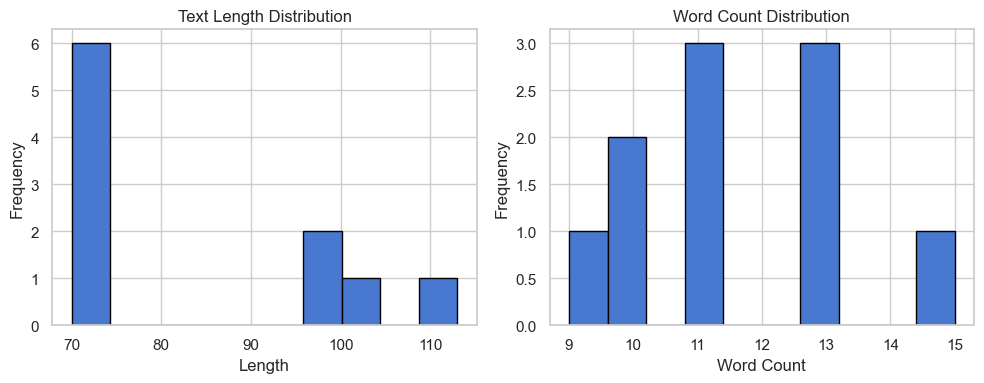

In [51]:
# Visualizations: text length distribution, word count distribution

df_no_null['word_count'] = df_no_null['document'].apply(lambda x: len(x.split()))
df_no_null['text_length'] = df_no_null['document'].apply(len)

plt.figure(figsize=(10, 4))

# Text Length Histogram
plt.subplot(1, 2, 1)
plt.hist(df_no_null['text_length'], bins=10, edgecolor='black')
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

# Word Count Histogram
plt.subplot(1, 2, 2)
plt.hist(df_no_null['word_count'], bins=10, edgecolor='black')
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Shape after outlier cleanup: (10, 3)


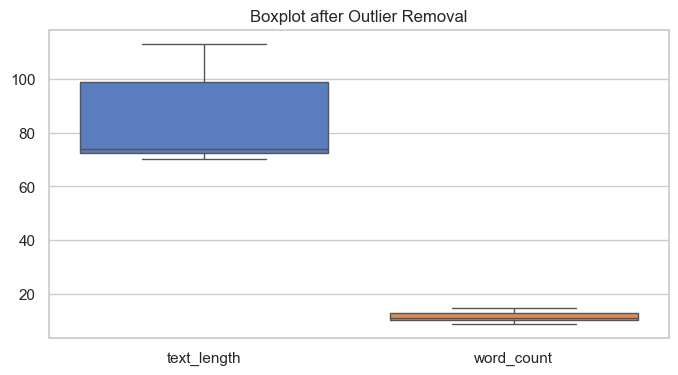

In [52]:
# Cell 9 – Outlier Removal on Text Length (IQR)
df_clean = df_no_null.copy()

q1    = df_clean['text_length'].quantile(0.25)
q3    = df_clean['text_length'].quantile(0.75)
iqr   = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean = df_clean[
    (df_clean['text_length'] >= lower) & (df_clean['text_length'] <= upper)
].reset_index(drop=True)

print('Shape after outlier cleanup:', df_clean.shape)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean[['text_length', 'word_count']])
plt.title('Boxplot after Outlier Removal')
plt.show()

In [53]:
# Cell 10 – Add Document Type & Encode
df_clean['doc_type'] = ['technical'] * 5 + ['general'] * (len(df_clean) - 5)

print('Document types:')
print(df_clean['doc_type'].value_counts())

le = LabelEncoder()
df_clean['doc_type_num'] = le.fit_transform(df_clean['doc_type'])
print('\nType mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

Document types:
doc_type
technical    5
general      5
Name: count, dtype: int64

Type mapping: {'general': np.int64(0), 'technical': np.int64(1)}


In [54]:
df_clean.head()

,document,text_length,word_count,doc_type,doc_type_num
0,Natural language processing is a subfield of l...,104,13,technical,1
1,Machine learning is the study of computer algo...,99,13,technical,1
2,"Data science combines statistics, programming,...",98,13,technical,1
3,Artificial intelligence aims to create machine...,113,15,technical,1
4,Text mining is the process of deriving high-qu...,74,11,technical,1


In [55]:
# Cell 11 – Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df_clean['cleaned_text'] = df_clean['document'].apply(clean_text)
df_clean[['document', 'cleaned_text']].head()

,document,cleaned_text
0,Natural language processing is a subfield of l...,natural language processing is a subfield of l...
1,Machine learning is the study of computer algo...,machine learning is the study of computer algo...
2,"Data science combines statistics, programming,...",data science combines statistics programming a...
3,Artificial intelligence aims to create machine...,artificial intelligence aims to create machine...
4,Text mining is the process of deriving high-qu...,text mining is the process of deriving highqua...


In [56]:
# Cell 12 – Task 1: Tokenization
sample_doc = df_clean['cleaned_text'].iloc[0]
print('Sample document:')
print(sample_doc)
print()

tokens = word_tokenize(sample_doc)
print('Tokenized tokens:')
print(tokens)

Sample document:
natural language processing is a subfield of linguistics computer science and artificial intelligence

Tokenized tokens:
['natural', 'language', 'processing', 'is', 'a', 'subfield', 'of', 'linguistics', 'computer', 'science', 'and', 'artificial', 'intelligence']


In [57]:
# Cell 13 – POS Tagging
pos_tags = pos_tag(tokens)
print('POS Tags:')
print(pos_tags)

POS Tags:
[('natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('is', 'VBZ'), ('a', 'DT'), ('subfield', 'NN'), ('of', 'IN'), ('linguistics', 'NNS'), ('computer', 'NN'), ('science', 'NN'), ('and', 'CC'), ('artificial', 'JJ'), ('intelligence', 'NN')]


In [58]:
# Cell 14 – Stop-words Removal
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]

print('After stop-words removal:')
print(filtered_tokens)

After stop-words removal:
['natural', 'language', 'processing', 'subfield', 'linguistics', 'computer', 'science', 'artificial', 'intelligence']


In [59]:
# Cell 15 – Stemming
stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in filtered_tokens]

print('After Stemming:')
print(stemmed)

After Stemming:
['natur', 'languag', 'process', 'subfield', 'linguist', 'comput', 'scienc', 'artifici', 'intellig']


In [60]:
# Cell 16 – Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]

print('After Lemmatization:')
print(lemmatized)

After Lemmatization:
['natural', 'language', 'processing', 'subfield', 'linguistics', 'computer', 'science', 'artificial', 'intelligence']


In [61]:
# Cell 17 – Task 2: TF-IDF Matrix
documents = df_clean['cleaned_text'].tolist()

tfidf_vec    = TfidfVectorizer(stop_words='english', max_features=100)
tfidf_matrix = tfidf_vec.fit_transform(documents)
feature_names = tfidf_vec.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print('TF-IDF Matrix shape:', tfidf_matrix.shape)
print('Top 10 terms:', feature_names[:10])
tfidf_df

TF-IDF Matrix shape: (10, 69)
Top 10 terms: ['abstract' 'aims' 'algorithms' 'analysis' 'artificial' 'automatically'
 'chatbots' 'classifies' 'collection' 'combines']


,abstract,aims,algorithms,analysis,artificial,automatically,chatbots,classifies,collection,combines,computer,continuous,conversation,create,data,deriving,determines,discovers,documents,domain,embeddings,emotional,entities,entity,experience,expertise,extract,highquality,human,identifies,improve,information,insights,intelligence,language,learning,linguistics,machine,machines,mining,modeling,named,natural,perform,process,processing,programming,recognition,represent,require,science,sentiment,series,simulate,space,statistics,study,subfield,tasks,text,tone,topic,topics,typically,use,vector,vectors,word,words
0,0.000000,0.00000,0.000000,0.000000,0.319968,0.000000,0.000000,0.000000,0.000000,0.00000,0.319968,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.319968,0.319968,0.000000,0.376393,0.000000,0.00000,0.000000,0.000000,0.000000,0.319968,0.00000,0.000000,0.319968,0.00000,0.000000,0.000000,0.00000,0.319968,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.376393,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.00000,0.359846,0.000000,0.000000,0.359846,0.000000,0.000000,0.000000,0.00000,0.305902,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.359846,0.00000,0.00000,0.000000,0.000000,0.000000,0.359846,0.000000,0.00000,0.000000,0.000000,0.359846,0.000000,0.359846,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.359846,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.29207,0.000000,0.000000,0.000000,0.00000,0.58414,0.000000,0.000000,0.000000,0.000000,0.29207,0.000000,0.000000,0.000000,0.000000,0.000000,0.29207,0.29207,0.000000,0.000000,0.000000,0.000000,0.000000,0.29207,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.29207,0.000000,0.000000,0.00000,0.248286,0.000000,0.000000,0.000000,0.000000,0.29207,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.29701,0.000000,0.000000,0.252486,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.29701,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.252486,0.000000,0.000000,0.000000,0.00000,0.504972,0.000000,0.000000,0.000000,0.000000,0.29701,0.000000,0.000000,0.000000,0.000000,0.29701,0.000000,0.000000,0.00000,0.000000,0.000000,0.29701,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.29701,0.000000,0.000000,0.000000,0.000000,0.29701,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.355995,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.355995,0.000000,0.000000,0.000000,0.355995,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.355995,0.000000,0.000000,0.000000,0.00000,0.355995,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.605257,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.00000,0.000000,0.385682,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.385682,0.000000,0.000000,0.00000,0.000000,0.385682,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0000

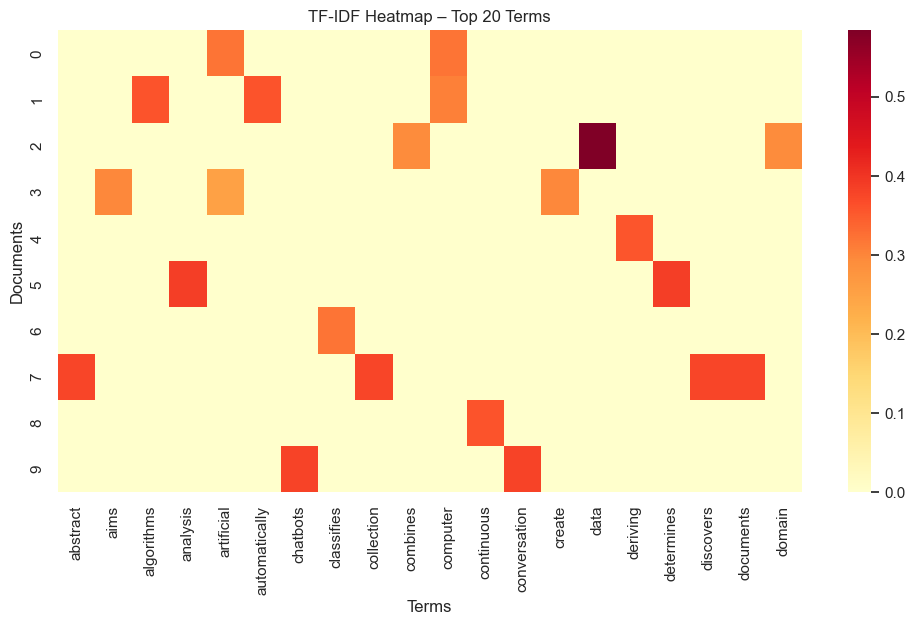

In [62]:
# Cell 18 – TF-IDF Heatmap (Top 20 Terms)
top_terms = feature_names[:20]

plt.figure(figsize=(12, 6))
sns.heatmap(tfidf_df[top_terms], annot=False, cmap='YlOrRd', cbar=True)
plt.title('TF-IDF Heatmap – Top 20 Terms')
plt.xlabel('Terms')
plt.ylabel('Documents')
plt.show()

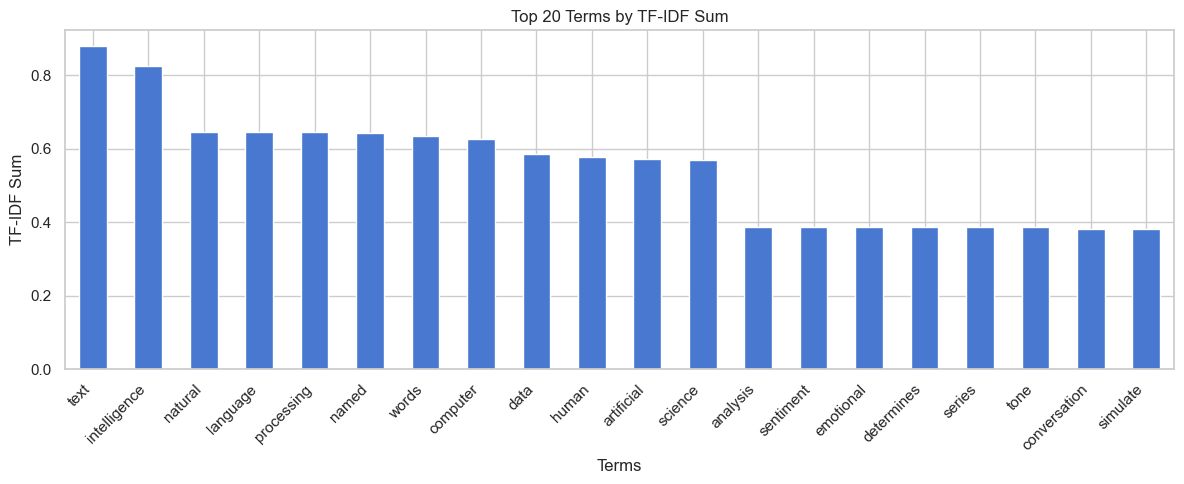

In [63]:
# Cell 19 – Term Frequency Bar Chart
term_freq = tfidf_df.sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
term_freq.head(20).plot(kind='bar')
plt.title('Top 20 Terms by TF-IDF Sum')
plt.xlabel('Terms')
plt.ylabel('TF-IDF Sum')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()